<center>
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML0101EN-SkillsNetwork/labs/Module%203/images/IDSNlogo.png" width="300" alt="cognitiveclass.ai logo">
</center>

# **Stacking For Classification**


## **Introduction**
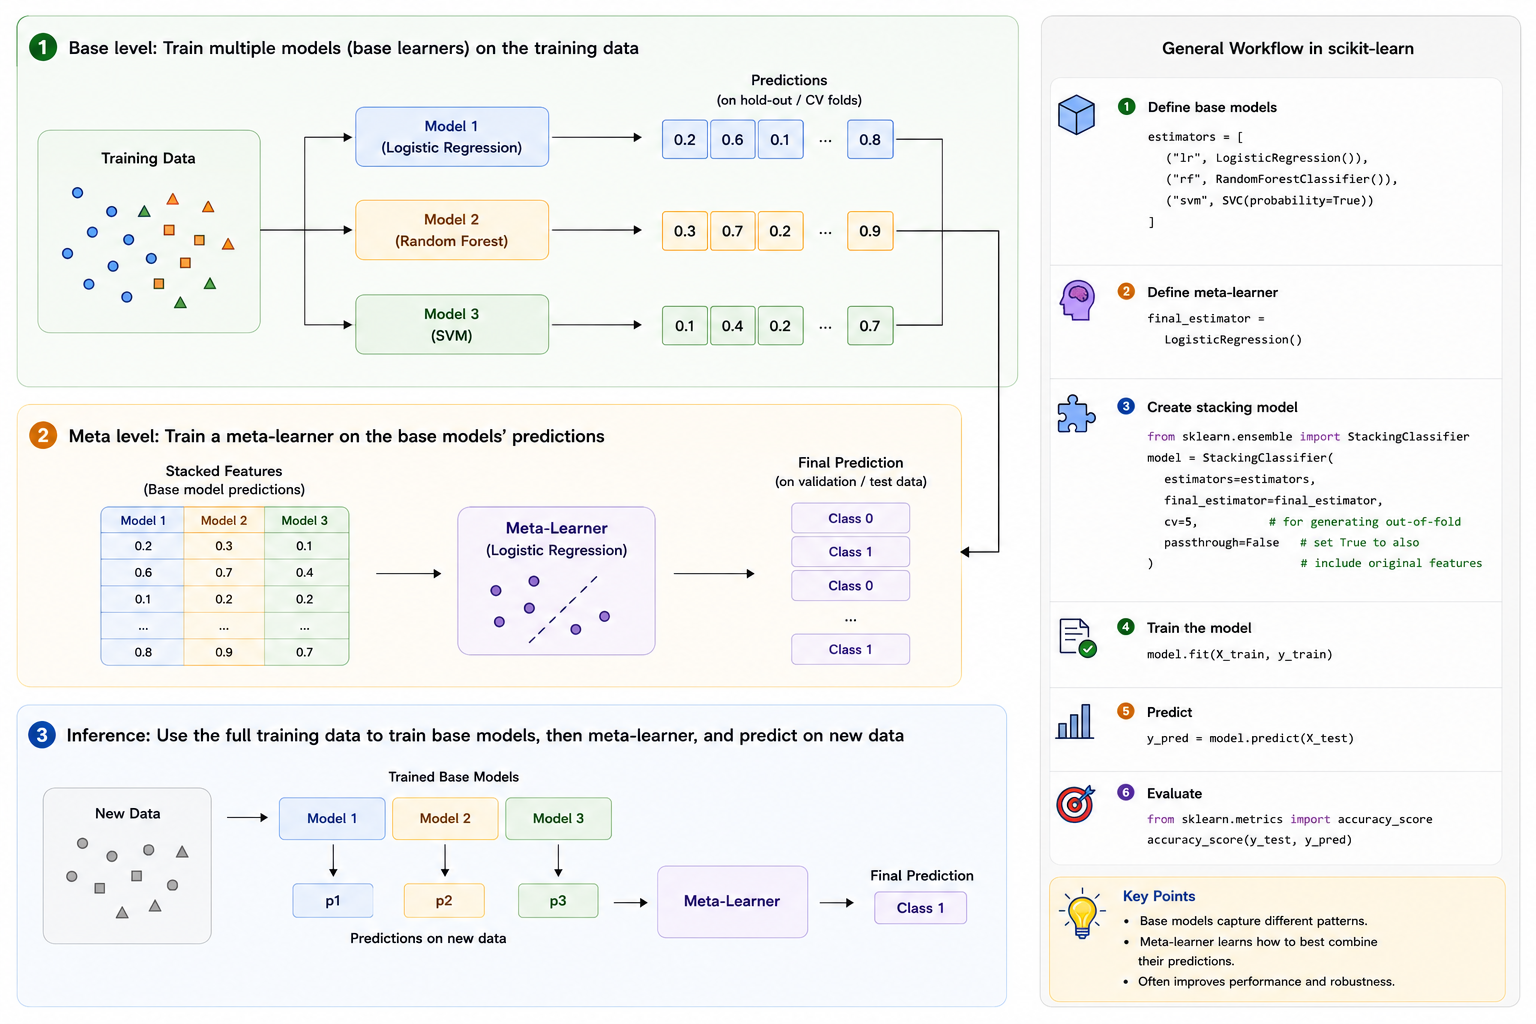
Stacking is an ensemble method, which means it combines several models to make one final prediction.

The first-level models are called **base learners**. Each base learner looks at the original input data and makes its own prediction. For example, in **Fig. 1**, the base learners $h_{1}(x)$, $h_{2}(x)$, $h_{3}(x)$, and $h_{4}(x)$ produce predictions $\hat{y}_{1}$, $\hat{y}_{2}$, $\hat{y}_{3}$, and $\hat{y}_{4}$.

Stacking then sends these predictions to a second-level model called the **meta-classifier**. The meta-classifier does not start from the original input features. Instead, it learns from the predictions made by the base learners. Its job is to combine those predictions and make the final prediction: $\hat{y}=H(\hat{y}_{1}, \hat{y}_{2}, \hat{y}_{3}, \hat{y}_{4})$.

A useful way to think about stacking is this: the base learners give several opinions, and the meta-classifier learns how to use those opinions to make a better final decision.


<center>
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-ML241EN-SkillsNetwork/labs/module5_Ensemble_Based_Methods/Screen_Shot_2022-01-12_at_9.40.33_PM.png" width="1000" alt="cognitiveclass.ai logo">
</center>
<center><b>Fig. 1</b> Base learners make predictions. The meta-classifier combines those predictions into one final prediction.</center>



A stacking model must be trained carefully. If the base learners and the meta-classifier are trained on exactly the same data, the model may overfit. 

To reduce this problem, stacking often uses **K-fold cross-validation** during training:

*   The training data is split into K folds.
*   The base learners are trained on K-1 folds.
*   The trained base learners make predictions on the remaining fold.
*   These predictions are used to train the meta-classifier.
*   The process is repeated so each fold is used once for meta-classifier training.

**Fig. 2** shows this idea with K=3. Each lower row is one cross-validation round. In each round, two folds train the base learners, and one fold is held out. The top row collects the predictions made on those held-out folds, and those predictions are used to train the meta-classifier.


<center>
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-ML241EN-SkillsNetwork/labs/module5_Ensemble_Based_Methods/stacking-kfold.png" width="1000" alt="cognitiveclass.ai logo">
</center>
<center><b>Fig. 2</b> Each lower row is one cross-validation round. Repeated colors in a row are a visual shortcut for folds used to train the base learners; they are not duplicated data. The one different color in that row is the held-out fold. The top row gathers the held-out predictions from all rounds to train the meta-classifier.</center>



### **Two Ways to Combine Classifiers**

Both `VotingClassifier` and `StackingClassifier` combine several models to make one final prediction. The main difference is how they combine the models.

#### **VotingClassifier**

`VotingClassifier` is the simpler method. Each model makes a prediction, and the final prediction is chosen by voting.

*   In **hard voting**, each model votes for a class label. The class with the most votes wins.
*   In **soft voting**, each model gives class probabilities. The probabilities are averaged, and the class with the highest average probability wins.
*   The voting method does not train a new model to combine the predictions.

#### **StackingClassifier**

`StackingClassifier` uses another model to combine the predictions from the base models. This final model is called the **meta-classifier**.

The training process has two levels:

*   The **base models** learn from the original input data.
*   The **meta-classifier** learns from the predictions made by the base models.

For example, suppose the base models are Logistic Regression, Decision Tree, and SVM. For each training example, each base model makes a prediction. These predictions are collected into a new training table:

| Logistic Regression prediction | Decision Tree prediction | SVM prediction | True class |
| --- | --- | --- | --- |
| 0 | 1 | 0 | 0 |
| 1 | 1 | 1 | 1 |
| 0 | 0 | 1 | 0 |

In this new table, the base models' predictions are the input features. The target is still the true class. The meta-classifier is trained on this table just like a normal classifier.

The meta-classifier can be different kinds of classifiers. In scikit-learn's `StackingClassifier`, the default meta-classifier is `LogisticRegression`. You can choose a different meta-classifier with the `final_estimator` parameter, such as `DecisionTreeClassifier` or `RandomForestClassifier`.

*In simple words, voting combines models with a fixed rule, such as majority vote or average probability. Stacking combines models by training a meta-classifier to learn how to use the base models' predictions.*


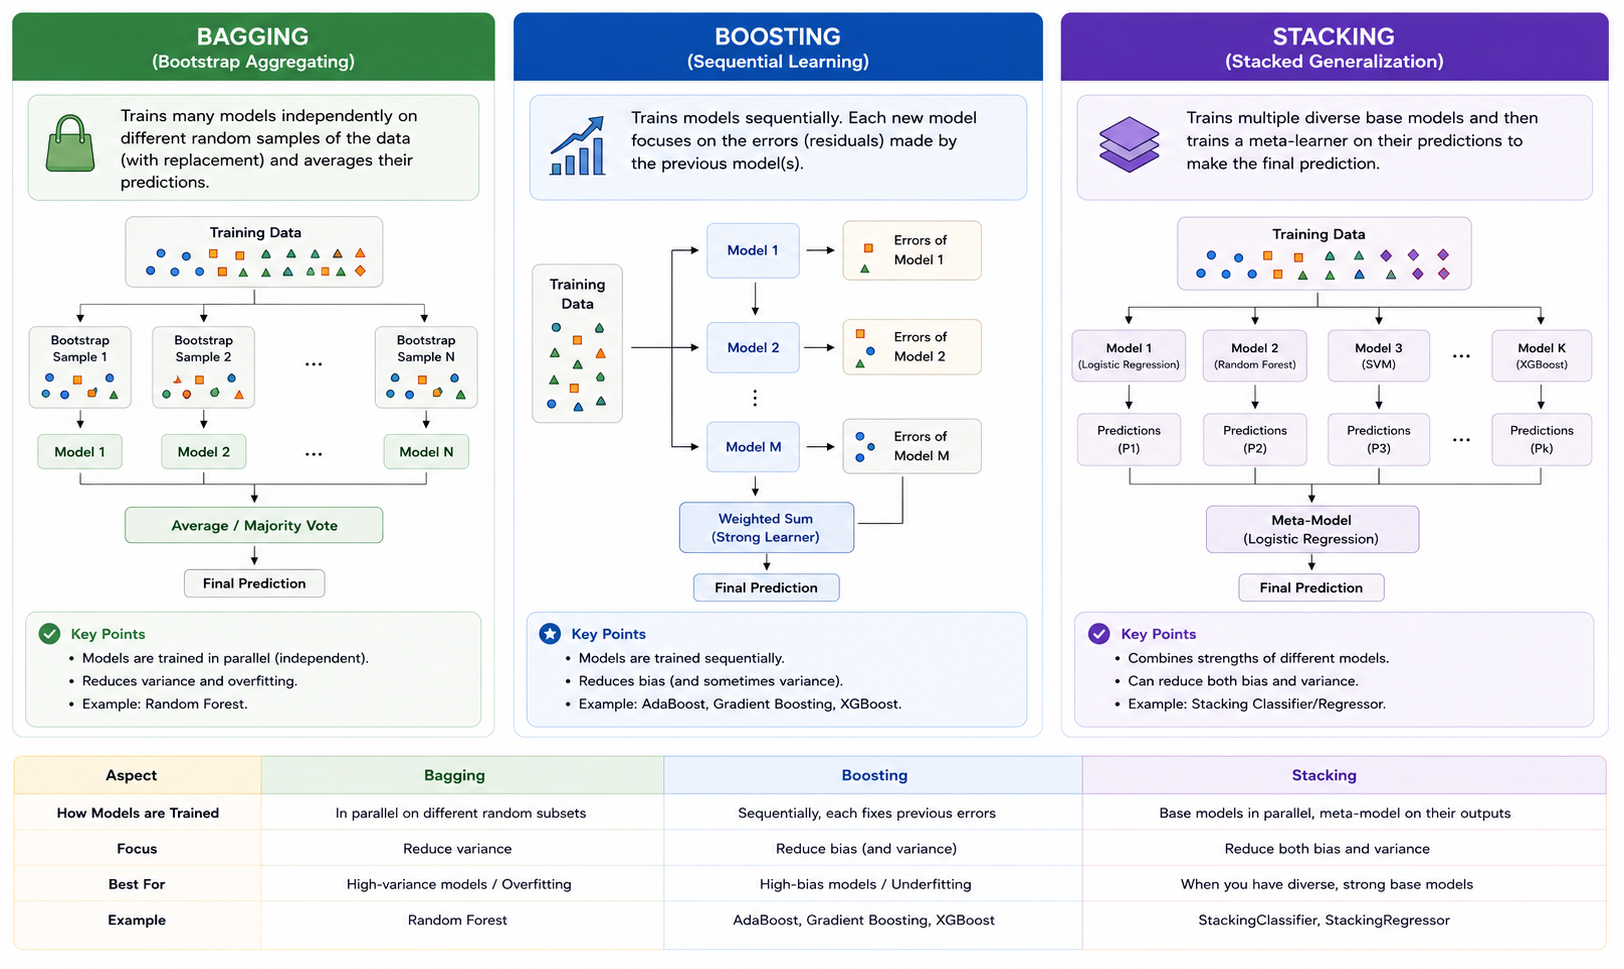

## **Objectives**

*   **Understand** what Stacking is and how it works
*   **Understand**  that Random Forests have less Correlation between predictors in their ensemble, improving accuracy
*   **Apply** Stacking
*   **Understand** Hyperparameters selection in  Stacking

## **Workflow**
### **Setup**
First, let's install and import the required libraries:


In [1]:
import numpy as np
import pandas as pd
import scipy.optimize as opt

import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

from sklearn import metrics
from sklearn import preprocessing
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

rs = 0

Ignore error warnings


In [2]:
import warnings

warnings.filterwarnings("ignore")

This function will calculate the accuracy of the training and testing data given a model.


In [3]:
def get_accuracy(X_train, X_test, y_train, y_test, model):
    return {
        "test Accuracy": metrics.accuracy_score(y_test, model.predict(X_test)),
        "trian Accuracy": metrics.accuracy_score(y_train, model.predict(X_train)),
    }

### **Wine Data Example**

The class is an essential factor in determining the quality of the wine; this dataset uses chemical analysis of wines grown in the same region in Italy from three different cultivars. Your task is to determine the class  of the wine using the features from the chemical analysis.
The features or attributes include

<pre>
1) Alcohol
2) Malic acid
3) Ash
4) Alcalinity of ash
5) Magnesium
6) Total phenols
7) Flavanoids
8) Nonflavanoid phenols
9) Proanthocyanins
10)Color intensity
11)Hue
12)OD280/OD315 of diluted wines
13)Proline
</pre>

For more info <a href="https://archive.ics.uci.edu/ml/datasets/wine?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML241ENSkillsNetwork31576874-2022-01-01">here </a>,let's load the dataset:


In [4]:
df = pd.read_csv(
    "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-ML241EN-SkillsNetwork/labs/datasets/wine.data",
    names=[
        "Class",
        "Alcohol",
        "Malic acid",
        "Ash",
        "Alcalinity of ash",
        "Magnesium",
        "Total phenols",
        "Flavanoids",
        "Nonflavanoid phenols",
        "Proanthocyanins",
        "Color intensity",
        "Hue",
        "OD280/OD315 of diluted wines",
        "Proline",
    ],
)

df.head()

,Class,Alcohol,Malic acid,Ash,Alcalinity of ash,Magnesium,Total phenols,Flavanoids,Nonflavanoid phenols,Proanthocyanins,Color intensity,Hue,OD280/OD315 of diluted wines,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


We see all the dataset is comprised of numerical values using the method <code>dtypes</code>


In [5]:
df.dtypes

Class                             int64
Alcohol                         float64
Malic acid                      float64
Ash                             float64
Alcalinity of ash               float64
Magnesium                         int64
Total phenols                   float64
Flavanoids                      float64
Nonflavanoid phenols            float64
Proanthocyanins                 float64
Color intensity                 float64
Hue                             float64
OD280/OD315 of diluted wines    float64
Proline                           int64
dtype: object

the column <code>class</code> has the class of the wine, we can use the method <code>unique()</code> to obtain the classes:


In [6]:
df["Class"].unique()

array([1, 2, 3])

We can examine the correlation between each feature and the class variable. By examining the first row or column we see the features are correlated with the class variable.


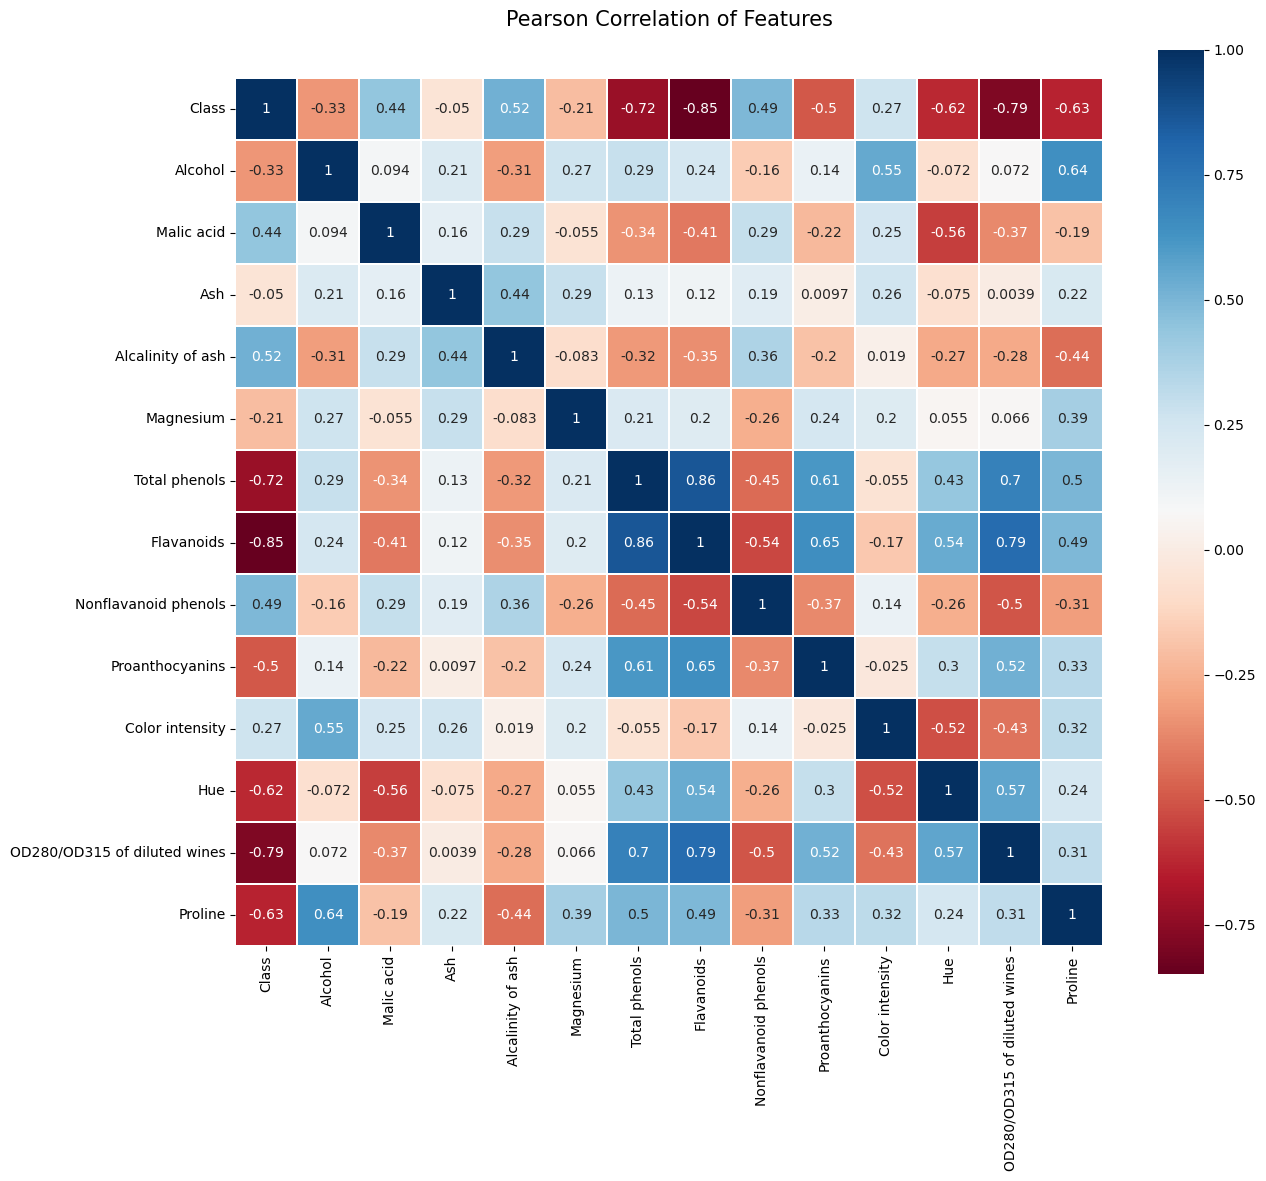

In [7]:
colormap = plt.cm.RdBu
plt.figure(figsize=(14, 12))
plt.title("Pearson Correlation of Features", y=1.05, size=15)
sns.heatmap(
    df.astype(float).corr(),
    linewidths=0.1,
    vmax=1.0,
    square=True,
    cmap=colormap,
    linecolor="white",
    annot=True,
)
plt.show()

We can also examine the <code>Pairplot</code> between pairs of features and the histogram; color-coded to each class. We see the separation between different classes:


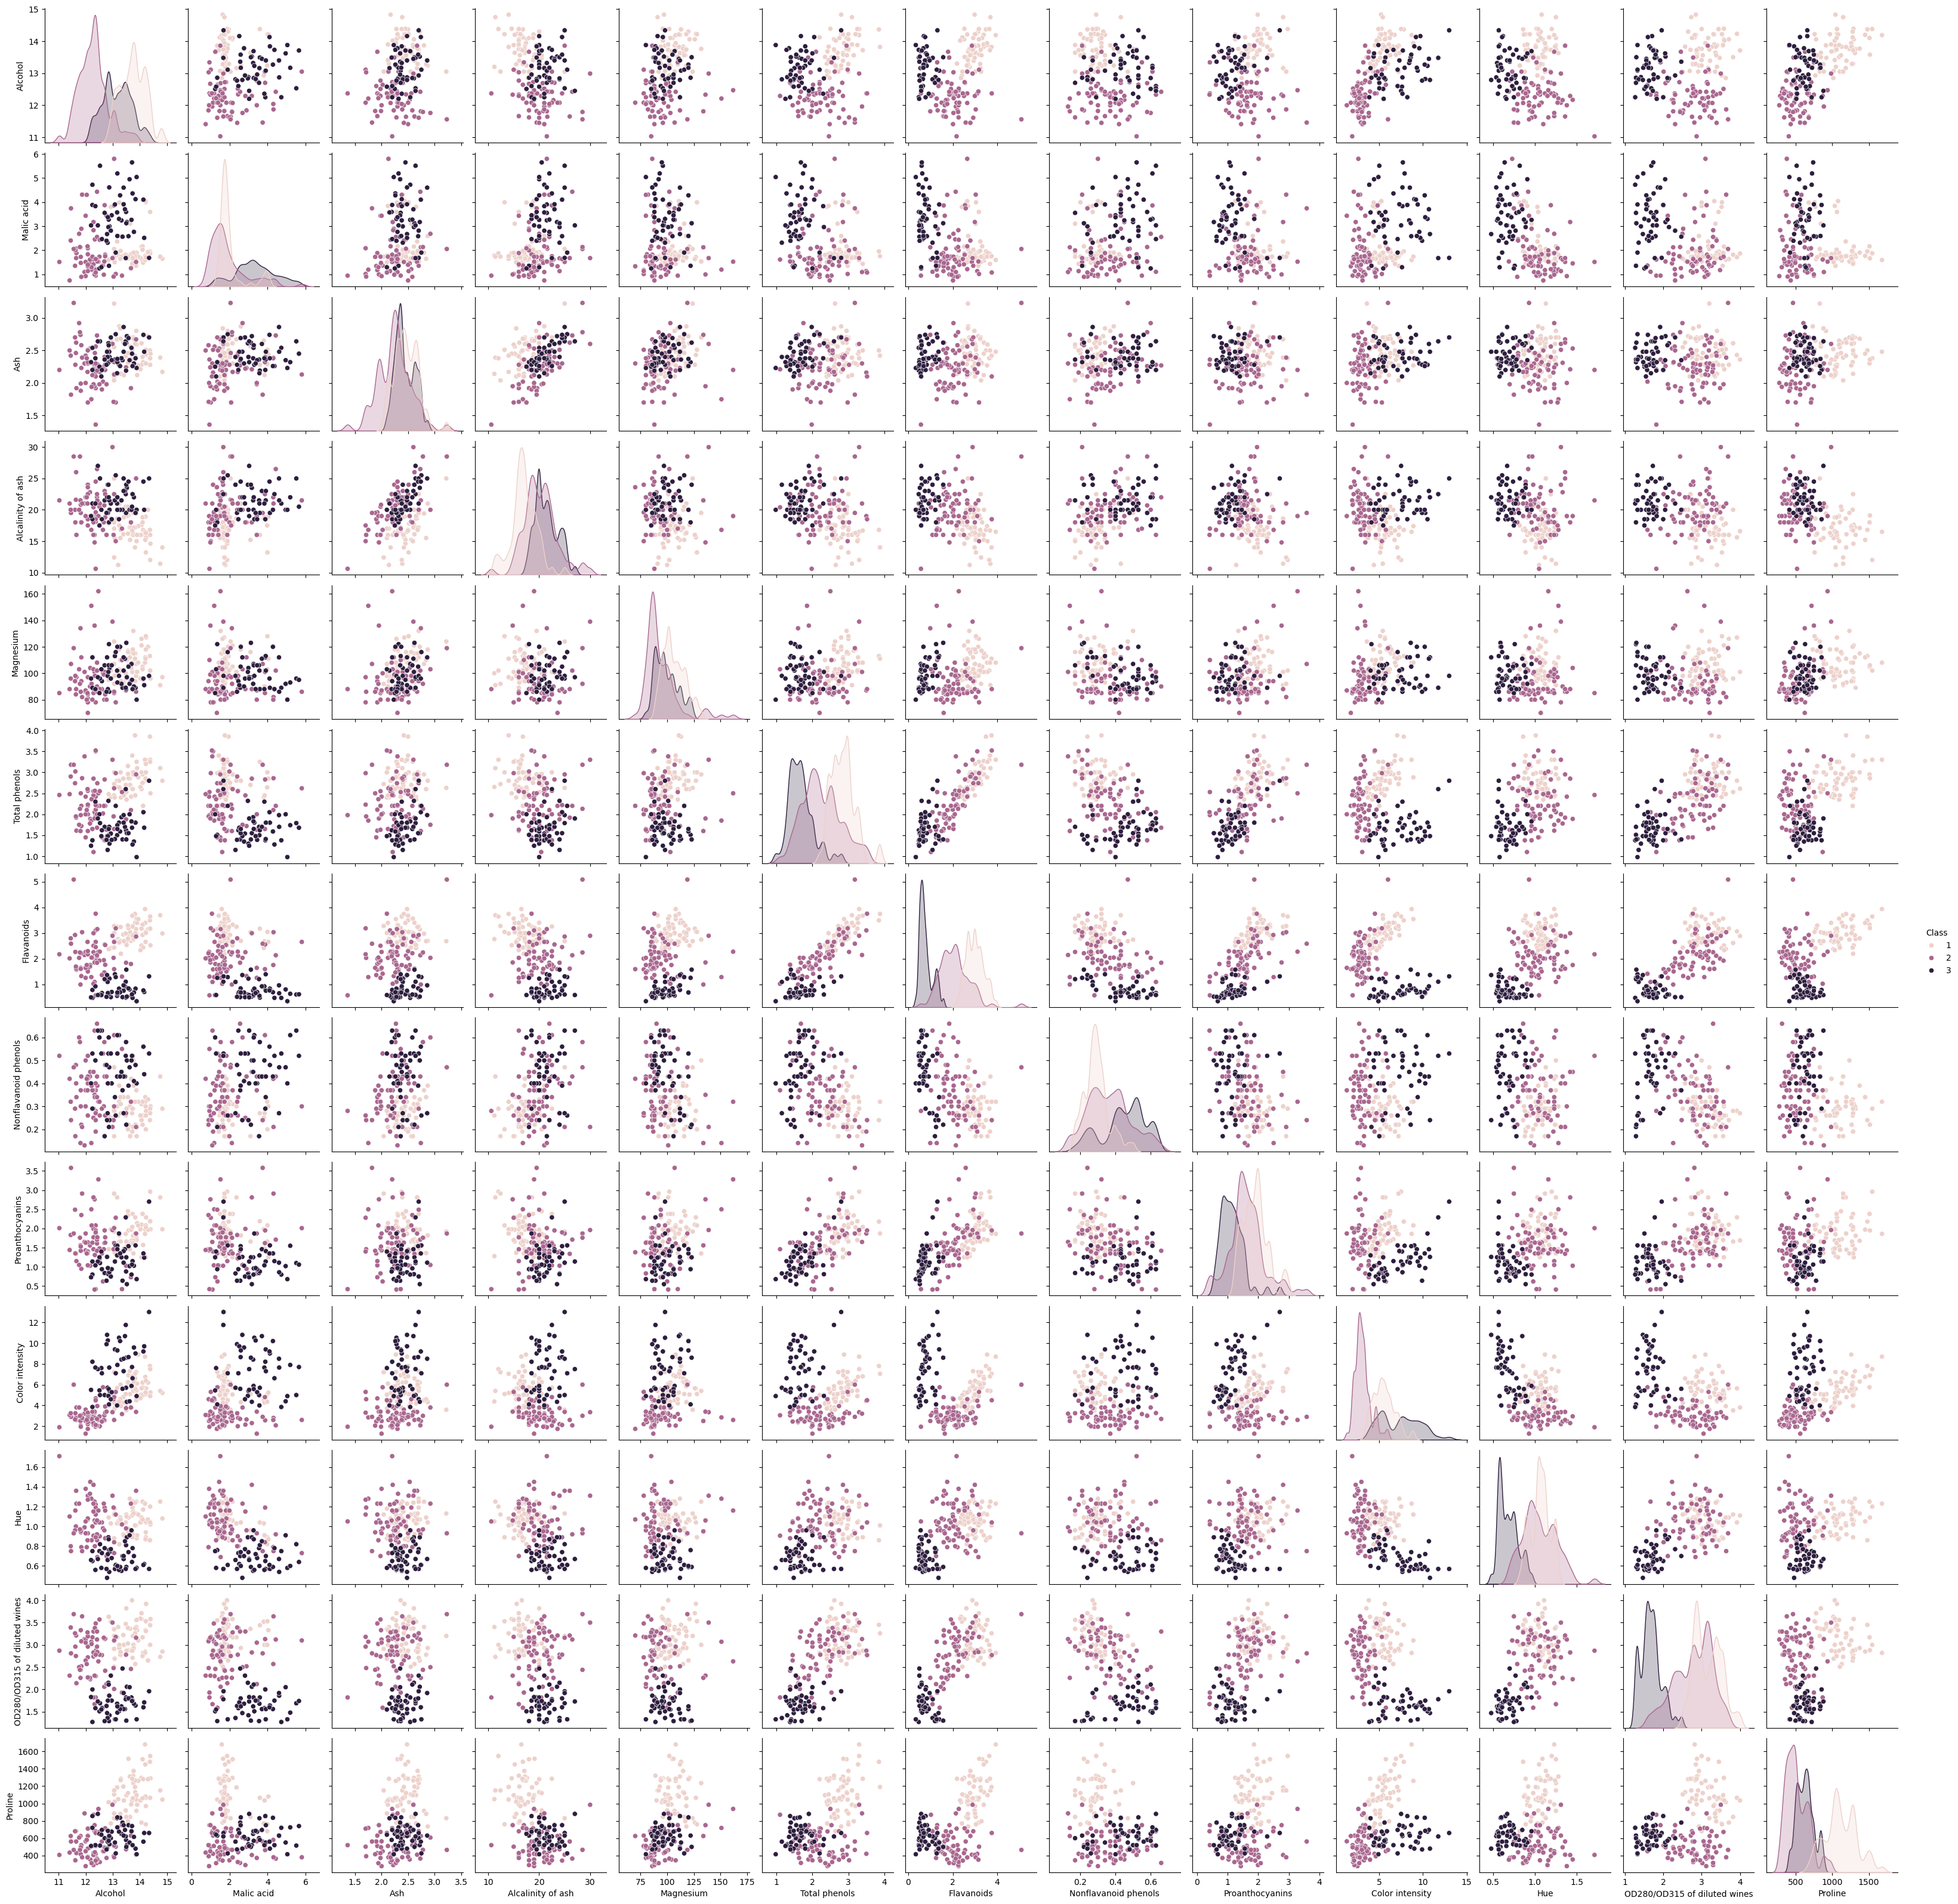

In [8]:
# May need to specify bandwidth (bw) in order to plot, else can delete the `, diag_kws={'bw': 0.2})` code.
sns.pairplot(df, hue="Class", diag_kws={"bw": 0.2})

#### **Data Pre-Processing and Selection**


Let’s examine the feature list


In [9]:
features = list(df)
features[1:]

['Alcohol',
 'Malic acid',
 'Ash',
 'Alcalinity of ash',
 'Magnesium',
 'Total phenols',
 'Flavanoids',
 'Nonflavanoid phenols',
 'Proanthocyanins',
 'Color intensity',
 'Hue',
 'OD280/OD315 of diluted wines',
 'Proline']

We assign the class variables to <code>y</code> and feature variables to <code>X</code>


In [10]:
y, X = df[features[0]], df[features[1:]]

We can standardize the data


In [11]:
scaler = preprocessing.StandardScaler().fit(X)
X = scaler.transform(X)

We can check if the data is standardized by checking the mean and standard deviation, which are approximately zero:


In [12]:
X.mean(axis=0)

array([-8.38280756e-16, -1.19754394e-16, -8.37033314e-16, -3.99181312e-17,
       -3.99181312e-17,  0.00000000e+00, -3.99181312e-16,  3.59263181e-16,
       -1.19754394e-16,  2.49488320e-17,  1.99590656e-16,  3.19345050e-16,
       -1.59672525e-16])

In [13]:
X.std(axis=0)

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

In Random Forest, we would use these data subsets to train each node of a tree.


#### **Train Test Split**


We split our dataset into train and test set:


In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=1, stratify=y
)
print("Train set", X_train.shape, y_train.shape)
print("Test set", X_test.shape, y_test.shape)

Train set (124, 13) (124,)
Test set (54, 13) (54,)


Stacking consists of creating a Stacking Classifier object, but first, you require a dictionary of <code>estimators</code> (individual model objects or base learners). The key of the dictionary is a name that is up to you, we use the usual acronym for the model. The value is the model object in this case SVC for Support Vector Classifier, dt for Decision Tree Classifier and KNN for K Neighbors Classifier.


In [15]:
estimators = [
    ("SVM", SVC(random_state=42)),
    ("KNN", KNeighborsClassifier()),
    ("dt", DecisionTreeClassifier()),
]
estimators

[('SVM', SVC(random_state=42)),
 ('KNN', KNeighborsClassifier()),
 ('dt', DecisionTreeClassifier())]

To train the final model we create a Stacking Classifier, this combines the base estimators using the meta estimator. The meta-classifier is determined by the parameter <code>final_estimator</code> in this case we use Logistic Regression, we also input the base classifiers using the <code>estimators</code> parameter and fit the model.


In [16]:
clf = StackingClassifier(estimators=estimators, final_estimator=LogisticRegression())
clf.fit(X_train, y_train)
clf

,estimators,"[('SVM', ...), ('KNN', ...), ...]"
,final_estimator,LogisticRegression()
,cv,None
,stack_method,'auto'
,n_jobs,None
,passthrough,False
,verbose,0
,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'


We can make a prediction


In [17]:
yhat = clf.predict(X_test)
yhat

array([3, 3, 3, 2, 2, 1, 2, 1, 2, 3, 3, 1, 2, 1, 3, 2, 1, 2, 1, 3, 1, 2,
       2, 1, 2, 3, 3, 2, 2, 2, 3, 2, 1, 2, 2, 2, 3, 2, 2, 3, 1, 3, 1, 1,
       1, 2, 1, 3, 2, 1, 2, 1, 1, 3])

We can obtain the training and testing accuracy, we see the model performs well.


In [18]:
get_accuracy(X_train, X_test, y_train, y_test, clf)

{'test Accuracy': 0.9814814814814815, 'trian Accuracy': 1.0}

<div style="color:red">


<div style="color:red">
   <b> Note: Like most complex models Stacking is prone to overfitting</b>


#### **Exercise**


Create a Stacking Classifier object as before but exchange the Decision Tree Classifier with the SVM classifier. Calculate the accuracy on the training and testing data.


In [19]:
estimators = [
    ("SVM", SVC(random_state=42)),
    ("KNN", KNeighborsClassifier()),
    ("lr", LogisticRegression()),
]
clf = StackingClassifier(
    estimators=estimators, final_estimator=DecisionTreeClassifier()
)
clf.fit(X_train, y_train)

get_accuracy(X_train, X_test, y_train, y_test, clf)

{'test Accuracy': 0.9814814814814815, 'trian Accuracy': 1.0}

### **Exercise: Course of Treatment Data**
The same course of treatment dataset is used for the tree-based methods in notebooks 3.5.1 to 3.5.5.

In [20]:
df = pd.read_csv(
    "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML0101EN-SkillsNetwork/labs/Module%203/data/drug200.csv",
    delimiter=",",
)
df.head()

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,drugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,drugY


Let's create the X and y for our dataset:


In [21]:
X = df[["Age", "Sex", "BP", "Cholesterol", "Na_to_K"]].values
X[0:5]

array([[23, 'F', 'HIGH', 'HIGH', 25.355],
       [47, 'M', 'LOW', 'HIGH', 13.093],
       [47, 'M', 'LOW', 'HIGH', 10.114],
       [28, 'F', 'NORMAL', 'HIGH', 7.798],
       [61, 'F', 'LOW', 'HIGH', 18.043]], dtype=object)

In [22]:
y = df["Drug"]
y[0:5]

0    drugY
1    drugC
2    drugC
3    drugX
4    drugY
Name: Drug, dtype: object

Now lets use a <code>LabelEncoder</code> to turn categorical features into numerical:


In [23]:
from sklearn import preprocessing

le_sex = preprocessing.LabelEncoder()
le_sex.fit(["F", "M"])
X[:, 1] = le_sex.transform(X[:, 1])


le_BP = preprocessing.LabelEncoder()
le_BP.fit(["LOW", "NORMAL", "HIGH"])
X[:, 2] = le_BP.transform(X[:, 2])


le_Chol = preprocessing.LabelEncoder()
le_Chol.fit(["NORMAL", "HIGH"])
X[:, 3] = le_Chol.transform(X[:, 3])

X[0:5]

array([[23, 0, 0, 0, 25.355],
       [47, 1, 1, 0, 13.093],
       [47, 1, 1, 0, 10.114],
       [28, 0, 2, 0, 7.798],
       [61, 0, 1, 0, 18.043]], dtype=object)

In [24]:
scaler = preprocessing.StandardScaler().fit(X)
X = scaler.transform(X)

Split the data into training and testing data with a 80/20 split


In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=4, stratify=y
)
print("Train set:", X_train.shape, y_train.shape)
print("Test set:", X_test.shape, y_test.shape)

Train set: (140, 5) (140,)
Test set: (60, 5) (60,)


#### **Stacking Classifiers**

We have our dictionary of estimators, the individual model objects or base learners.


In [26]:
estimators = [
    ("SVM", SVC(random_state=42)),
    ("knn", KNeighborsClassifier()),
    ("dt", DecisionTreeClassifier()),
]
estimators

[('SVM', SVC(random_state=42)),
 ('knn', KNeighborsClassifier()),
 ('dt', DecisionTreeClassifier())]

We create a Stacking Classifier:


In [27]:
clf = StackingClassifier(estimators=estimators, final_estimator=LogisticRegression())
clf

,estimators,"[('SVM', ...), ('knn', ...), ...]"
,final_estimator,LogisticRegression()
,cv,None
,stack_method,'auto'
,n_jobs,None
,passthrough,False
,verbose,0
,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'


#### **GridSearchCV**
In order to alter the base models in the dictionary of hyperparameter values, we add the key value of each model followed by the parameter of the model we would like to vary.


In [28]:
param_grid = {
    "dt__max_depth": [n for n in range(10)],
    "dt__random_state": [0],
    "SVM__C": [0.01, 0.1, 1],
    "SVM__kernel": ["linear", "poly", "rbf"],
    "knn__n_neighbors": [1, 4, 8, 9],
}

We use <code>GridSearchCV</code> to search over specified parameter values of the model. Because this is a classification problem, we use <code>StratifiedKFold</code> for cross-validation. It shuffles the data before making the folds and keeps the class proportions similar in each fold.


In [29]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=rs)
search = GridSearchCV(estimator=clf, param_grid=param_grid, scoring="accuracy", cv=cv)
search.fit(X_train, y_train)

,estimator,StackingClass...cRegression())
,param_grid,"{'SVM__C': [0.01, 0.1, ...], 'SVM__kernel': ['linear', 'poly', ...], 'dt__max_depth': [0, 1, ...], 'dt__random_state': [0], ...}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,0.01


We can find the accuracy of the best model.


In [30]:
search.best_score_

0.9928571428571429

We can find the best parameter values:


In [31]:
search.best_params_

{'SVM__C': 0.01,
 'SVM__kernel': 'linear',
 'dt__max_depth': 4,
 'dt__random_state': 0,
 'knn__n_neighbors': 4}

We can find the accuracy test data:


In [32]:
get_accuracy(X_train, X_test, y_train, y_test, search)

{'test Accuracy': 1.0, 'trian Accuracy': 1.0}

## **Author**

<a href="https://www.linkedin.com/in/joseph-s-50398b136/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDeveloperSkillsNetworkML0101ENSkillsNetwork20718538-2021-01-01" target="_blank">Joseph Santarcangelo</a>, Su Wu

### **Other Contributors**

<a href="https://www.linkedin.com/in/richard-ye/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDeveloperSkillsNetworkML0101ENSkillsNetwork20718538-2021-01-01" target="_blank">Richard Ye</a>

## <h3 align="center"> © IBM Corporation 2021. All rights reserved. <h3/>

<!--## Change Log

| Date (YYYY-MM-DD) | Version | Changed By | Change Description          |
| ----------------- | ------- | ---------- | --------------------------- |
| 2021-01-01        | 1.0     | Joseph S   | Created the initial version |
| 2022-02-09        | 1.1     | Steve Hord | QA pass                     |
| 2022-05-03        | 1.2     | Richard Ye | Updated sklearn package to `0.22.1` to remove errors |--!>


